# Langgraph 실습

## State 기획 필요

## Node
1. START - 사용자의 아픈 증상을 메세지 입력
2. 메세지를 기반으로 증상 추출 (LLM)
3. *증상별로 도움되는 영양소를 뽑아줌* (**LLM with Structured Output**) - Agent 아님. `llm.invoke`
    - `symptom: str` -> 증상
    - `nutrients: list[str]` -> 추천하는 영양소 목록
    - `reason: str` -> 각 영양소를 추천한 종합 소견
4. 증상 + 영양소 목록으로 최종 안내문 생성 (LLM)
5. END

In [8]:
import os
from dotenv import load_dotenv
from typing_extensions import TypedDict, List
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# 환경 변수 로드 (.env의 OPENAI_API_KEY 사용)
load_dotenv()

# 공통 LLM 모델 초기화
llm = init_chat_model('openai:gpt-4.1-mini')



In [9]:
# ---------------------------------------------------------
# 1. State 정의 및 Structured Output용 Pydantic 모델 정의
# ---------------------------------------------------------

class NutrientRecommendation(BaseModel):
    """영양소 추천을 위한 Structured Output 스키마"""
    symptom: str = Field(description="사용자가 겪고 있는 핵심 증상")
    nutrients: List[str] = Field(description="증상 완화 및 건강에 도움을 주는 영양소 목록")
    reason: str = Field(description="해당 영양소들을 추천한 종합 소견 및 이유")


class HealthState(TypedDict):
    """노드 간 전달될 데이터 상태 정의"""
    message: str                # 1. 사용자의 초기 입력 메세지
    extracted_symptom: str      # 2. 메세지에서 추출된 주요 증상
    nutrients: List[str]        # 3. 추천 영양소 목록
    reason: str                 # 3. 추천 종합 소견
    answer: str                 # 4. 사용자에게 전달할 최종 안내문



In [ ]:
# ---------------------------------------------------------
# 2. Node 함수 정의
# ---------------------------------------------------------

def extract_symptom_node(state: HealthState):
    """Node 1: 사용자의 메세지로부터 핵심 증상을 추출"""
    user_message = state['message']
    
    response = llm.invoke([
        SystemMessage(content="사용자의 메세지에서 가장 주된 건강 문제나 증상 키워드(예: 눈 피로, 만성 피로, 소화 불량 등)를 명확하게 단어나 짧은 구 형태로 추출해주세요. 다른 설명 없이 추출된 증상만 답변하세요."),
        HumanMessage(content=user_message)
    ])
    
    return {'extracted_symptom': response.content.strip()}


def recommend_nutrients_node(state: HealthState):
    """Node 2: Structured Output을 활용해 증상별 영양소 및 소견 도출"""
    symptom = state['extracted_symptom']
    
    # LLM에 Structured Output 바인딩
   
    
    
    result: NutrientRecommendation = structured_llm.invoke([
        SystemMessage(content="당신은 전문 영양사입니다. 전달받은 증상에 효과적인 영양소 목록과 그 이유를 구체적인 소견으로 작성해주세요."),
        HumanMessage(content=f"증상: {symptom}")
    ])
    
    return {
        'nutrients': result.nutrients,
        'reason': result.reason
    }


def make_guide_node(state: HealthState):
    """Node 3: 증상과 영양소 목록, 소견을 종합해 최종 안내문 작성"""
    symptom = state['extracted_symptom']
    nutrients = state['nutrients']
    reason = state['reason']
    
    response = llm.invoke([
        SystemMessage(content="당신은 친절한 헬스케어 어시스턴트입니다. 증상, 추천 영양소, 전문가 소견을 바탕으로 사용자에게 정중하고 읽기 편한 최종 안내 가이드를 작성해주세요. 주의사항(의사 상담 권고 등)도 덧붙여주세요."),
        HumanMessage(content=f"""
- 증상: {symptom}
- 추천 영양소: {', '.join(nutrients)}
- 추천 소견: {reason}
""")
    ])
    
    return {'answer': response.content}




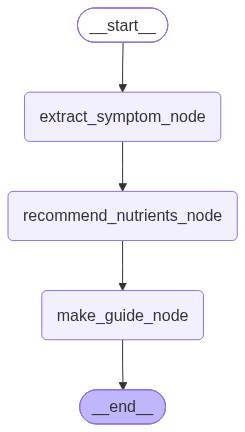

In [11]:
# ---------------------------------------------------------
# 3. StateGraph 빌드 및 연결
# ---------------------------------------------------------

builder = StateGraph(HealthState)

# 노드 등록
builder.add_node('extract_symptom_node', extract_symptom_node)
builder.add_node('recommend_nutrients_node', recommend_nutrients_node)
builder.add_node('make_guide_node', make_guide_node)

# 엣지 연결 (순차 실행 파이프라인)
builder.add_edge(START, 'extract_symptom_node')
builder.add_edge('extract_symptom_node', 'recommend_nutrients_node')
builder.add_edge('recommend_nutrients_node', 'make_guide_node')
builder.add_edge('make_guide_node', END)

# 그래프 컴파일
graph = builder.compile()
graph



In [12]:
# ---------------------------------------------------------
# 4. 실행 테스트

# 테스트 1 (소화기 계통):
# "밥만 먹으면 속이 더부룩하고 가스가 많이 차요. 가끔 명치 쪽이 쓰리기도 합니다."

# 테스트 2 (근골격/피로 계통):
# "운동을 시작했는데 자고 일어나면 종아리에 쥐가 자주 나고 근육통이 며칠씩 가요."

# 테스트 3 (수면/신경 계통):
# "밤에 침대에 누워도 잠들기까지 1~2시간씩 걸리고, 자다가도 자꾸 깨서 아침에 머리가 멍해요."
# ---------------------------------------------------------

if __name__ == "__main__":
    test_input = {
        'message': "밤에 침대에 누워도 잠들기까지 1~2시간씩 걸리고, 자다가도 자꾸 깨서 아침에 머리가 멍해요."
    }
    
    final_state = graph.invoke(test_input)
    
    print("=== [추출된 증상] ===")
    print(final_state['extracted_symptom'])
    print("\n=== [추천 영양소 목록] ===")
    print(final_state['nutrients'])
    print("\n=== [전문가 소견] ===")
    print(final_state['reason'])
    print("\n=== [최종 안내문] ===")
    print(final_state['answer'])

=== [추출된 증상] ===
불면증, 수면 유지 장애, 아침 불쾌감

=== [추천 영양소 목록] ===
['멜라토닌', '마그네슘', '비타민 B6', '트립토판', '오메가-3 지방산']

=== [전문가 소견] ===
불면증과 수면 유지 장애는 신경계의 불균형과 스트레스, 신경 전달 물질의 부족과 관련이 있습니다. 멜라토닌은 수면-각성 주기를 조절하는 호르몬으로, 복용 시 수면 질 개선에 도움을 줍니다. 마그네슘은 신경 안정 작용이 있어 긴장을 완화하고 깊은 수면을 유도합니다. 비타민 B6는 트립토판이 세로토닌과 멜라토닌으로 전환되는 데 필수적인 조효소 역할을 하여 수면 개선에 기여합니다. 트립토판은 세로토닌 및 멜라토닌 합성의 전구체로, 기분 안정 및 수면 유도를 돕습니다. 오메가-3 지방산은 뇌 기능과 기분 조절에 긍정적인 영향을 미쳐 아침 불쾌감 완화에 기여할 수 있습니다.

=== [최종 안내문] ===
안녕하세요. 불면증과 수면 유지 장애, 그리고 아침에 느끼는 불쾌감으로 어려움을 겪고 계시다니 많이 힘드시겠어요. 이러한 증상은 신경계의 불균형과 스트레스, 그리고 신경 전달 물질의 부족과 관련이 있을 수 있습니다.

수면의 질을 개선하고 편안한 아침을 맞이하기 위해 다음과 같은 영양소를 고려해 보시길 권장드립니다.

1. **멜라토닌**  
수면-각성 주기를 조절하는 호르몬으로, 적절한 복용 시 수면의 깊이와 질을 높여주며 빠른 수면 유도에 도움을 줄 수 있습니다.

2. **마그네슘**  
신경 안정 작용이 뛰어나 긴장을 완화시키고 깊고 편안한 수면을 유도하는 데 기여합니다.

3. **비타민 B6**  
트립토판이 세로토닌과 멜라토닌으로 전환되는 데 필수적인 조효소로 작용하여, 수면 리듬을 개선하는 데 도움을 줍니다.

4. **트립토판**  
기분 안정과 수면 유도에 도움을 주는 세로토닌 및 멜라토닌 합성의 전구체입니다.

5. **오메가-3 지방산**  
뇌 기능과 기분 조절에 긍정적인 영향을 미쳐 아침의 불쾌감 완화에 도움이 될 수 있

In [13]:
# 실행부: 증상 입력 및 최종 답변 출력
res = graph.invoke({
    'message': '밤에 침대에 누워도 잠들기까지 1~2시간씩 걸리고, 자다가도 자꾸 깨서 아침에 머리가 멍해요.'
})

print(res['answer'])

안녕하세요. 불면증, 수면 중단, 아침 두통으로 어려움을 겪고 계신 점 안타깝게 생각합니다. 이러한 증상 개선에 도움이 되는 영양소와 생활관리법에 대해 안내해 드리겠습니다.

1. 마그네슘  
마그네슘은 근육 이완과 신경 안정에 중요한 역할을 하여 수면의 질을 향상시키는 데 도움을 줍니다. 마그네슘이 풍부한 견과류, 녹색 잎채소, 통곡물 등을 섭취해 보세요.  

2. 멜라토닌  
멜라토닌은 생체리듬(수면-각성 주기)을 조절하는 호르몬으로, 수면을 시작하고 유지하는 데 효과적입니다. 멜라토닌 보충제는 자기 전에 복용하면 도움이 될 수 있으나, 복용 전 전문가 상담을 권장합니다.  

3. 비타민 B6  
비타민 B6는 세로토닌과 멜라토닌 합성에 필수적인 영양소로 기분 안정과 수면 유도에 도움을 줍니다. 닭고기, 바나나, 감자 등에서 섭취할 수 있습니다.  

4. 트립토판  
트립토판은 세로토닌의 전구물질로, 기분 개선과 수면 유도에 기여합니다. 트립토판이 풍부한 음식으로는 칠면조, 계란, 유제품 등이 있습니다.  

5. 오메가-3 지방산  
오메가-3 지방산은 뇌 기능을 개선하고 염증을 감소시켜 수면의 질을 높이며, 특히 아침 두통 완화에도 효과적입니다. 생선, 아마씨, 호두 등에 포함되어 있습니다.  

**주의사항 및 권장사항**  
- 위 영양소는 균형 잡힌 식사를 통해 섭취하는 것이 가장 좋으며, 보충제 사용을 고려하실 경우 반드시 전문가(의사 또는 영양사)와 상담하시기 바랍니다.  
- 지속적인 불면증 및 아침 두통은 다른 건강 문제의 신호일 수 있으므로, 증상이 심하거나 장기간 지속된다면 전문 의료기관을 방문하여 정확한 진단과 치료를 받으시길 권유드립니다.  
- 수면 환경 개선(규칙적인 수면 습관, 적절한 수면 환경 조성) 및 스트레스 관리 또한 중요합니다.  

적절한 영양 섭취와 생활습관 개선으로 증상이 완화되길 바라며, 건강한 수면으로 일상 생활에 활력이 넘치시길 응원합니다.
